### Decision Tree Classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset('iris')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
df['species'] = df['species'].map({"setosa":0,"versicolor":1,"virginica":2})
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
X = df.drop(columns='species')
y = df['species']

In [8]:
classifier = DecisionTreeClassifier(random_state=42,max_depth=6,ccp_alpha=0.01)
classifier.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.9, 'x[2] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = setosa'),
 Text(0.3333333333333333, 0.7, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = setosa'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.6666666666666666, 0.7, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = versicolor'),
 Text(0.5833333333333333, 0.8, '  False'),
 Text(0.5, 0.5, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = versicolor'),
 Text(0.3333333333333333, 0.3, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]\nclass = versicolor'),
 Text(0.16666666666666666, 0.1, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]\nclass = versicolor'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.6666666666666666, 0.3, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]\nclass = virginica'),
 Text(0.8333333333333334, 0.5, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]\nclass = virginica')]

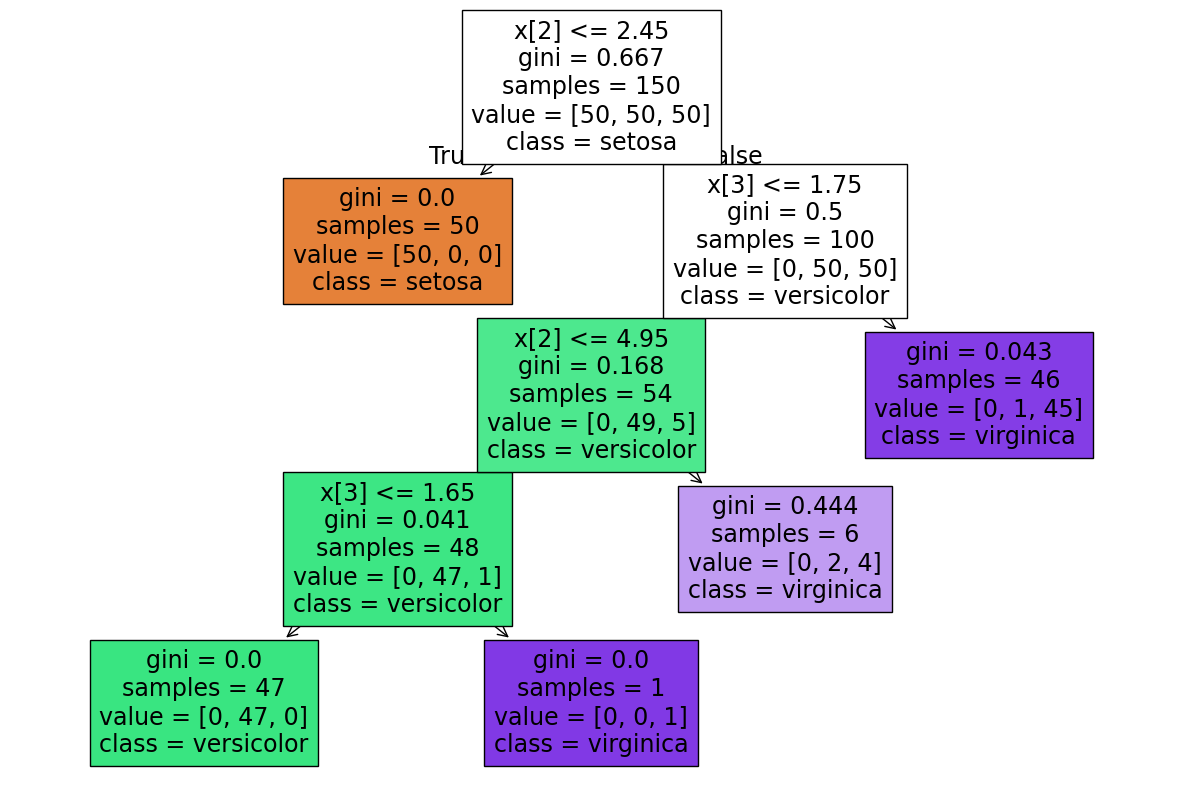

In [9]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(classifier, filled=True, class_names=["setosa", "versicolor", "virginica"])

In [10]:
from sklearn.model_selection import train_test_split,GridSearchCV

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
clf = DecisionTreeClassifier(random_state=42)


In [12]:
params = {
    'criterion':['entropy','gini'],
    'max_depth':[2,4,5,6,8,10,12,15,30],
    'min_samples_split':[2,3,4,5],
    'min_samples_leaf':[1,2,4,5]
}

grid = GridSearchCV(estimator=clf,param_grid = params,cv=5,scoring="accuracy")
grid.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [13]:
print("\nBest Hyperparameters:", grid.best_params_)
print("Best CV Score from GridSearch:", grid.best_score_)
y_pred = grid.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score from GridSearch: 0.9583333333333334
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
# Step 10: Predict for a new sample
new_sample = [[5.5, 3.2, 1.4, 0.2]]  # example flower features
new_df = pd.DataFrame(new_sample,columns=X.columns)
predicted_class = grid.predict(new_df)
species_map = {0: "setosa", 1: "versicolor", 2: "virginica"}
print(species_map[predicted_class[0]])


setosa


In [15]:
# Make a DataFrame with same column names as training data
new_sample = [[6.3, 3.3, 6.0, 2.5]]
new_df = pd.DataFrame(new_sample, columns=X.columns)

# Predict
predicted_class = grid.predict(new_df)
print(predicted_class,predicted_class[0])  # [0]
# If you want to map the class to a name, use:

print("Predicted flower:", species_map[predicted_class[0]])


[2] 2
Predicted flower: virginica


DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4,
                       random_state=42)


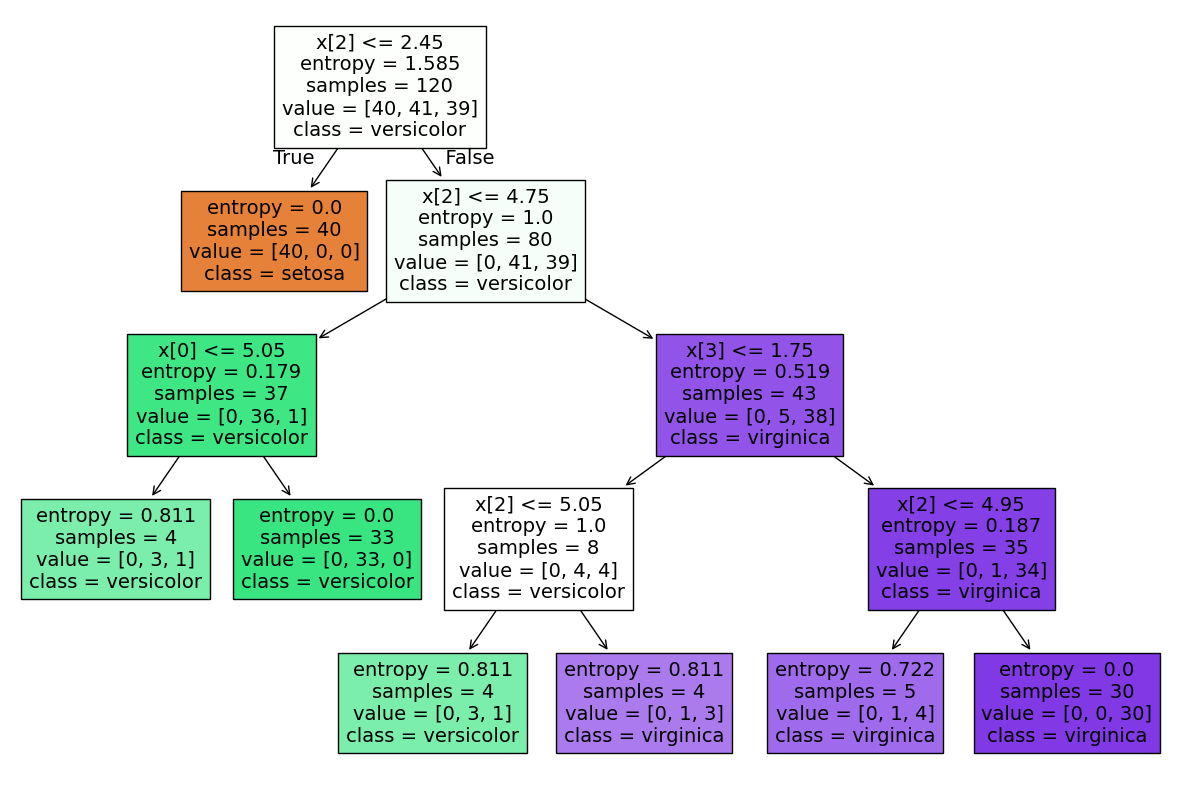

In [16]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(grid.best_estimator_, filled=True, class_names=["setosa", "versicolor", "virginica"])
print(grid.best_estimator_)

In [17]:
# Training accuracy
train_acc = grid.best_estimator_.score(X_train, y_train)

# Test accuracy
test_acc = grid.best_estimator_.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Training Accuracy: 0.9666666666666667
Test Accuracy: 1.0


In [18]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(grid.best_estimator_, X_train, y_train, cv=5)
print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())


CV Scores: [1.         1.         0.83333333 1.         0.95833333]
Mean CV Score: 0.9583333333333334


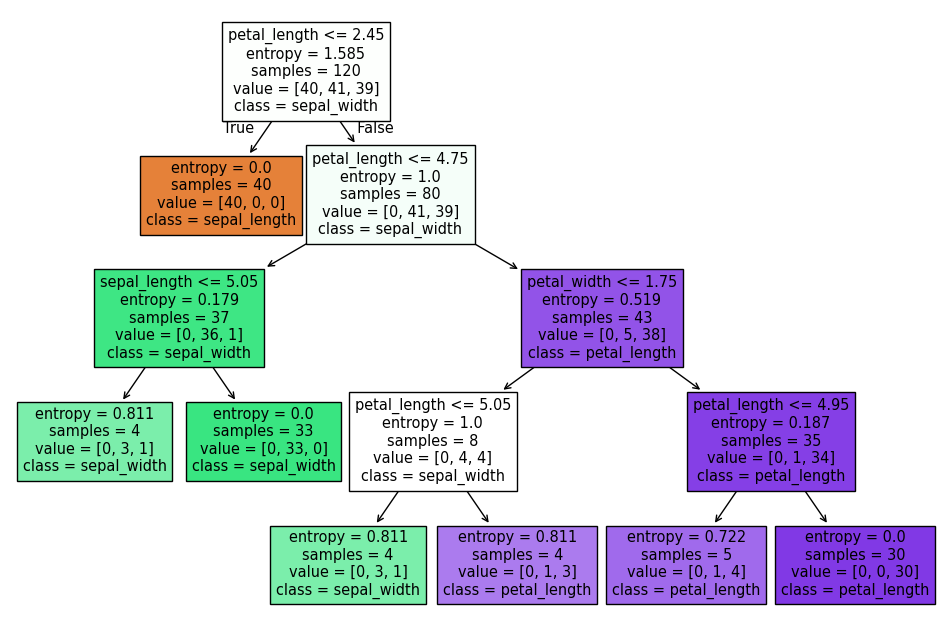

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(grid.best_estimator_, feature_names=X.columns, class_names=X.columns, filled=True)
plt.show()


### Decision Regression 


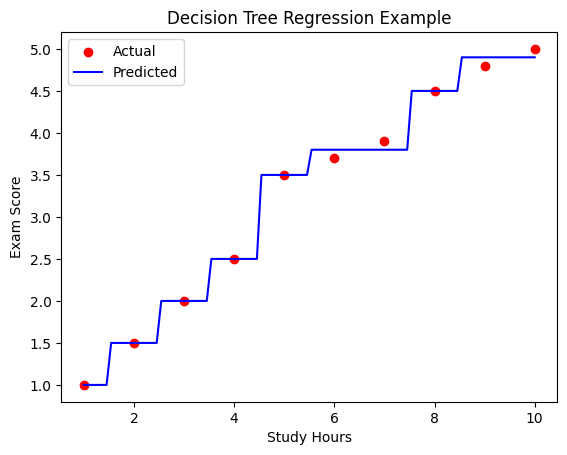

In [20]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

# Sample data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])  # study hours
y = np.array([1, 1.5, 2, 2.5, 3.5, 3.7, 3.9, 4.5, 4.8, 5])        # exam score

# Train regression tree
reg = DecisionTreeRegressor()
params = {
    'max_depth':[2,3,4,5,7,6],
}
reg = GridSearchCV(reg,params,cv=5)
reg.fit(X, y)

# Predictions
X_test = np.linspace(1, 10, 100).reshape(-1, 1)
y_pred = reg.predict(X_test)

# Plot
plt.scatter(X, y, color="red", label="Actual")
plt.plot(X_test, y_pred, color="blue", label="Predicted")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Decision Tree Regression Example")
plt.legend()
plt.show()
